# Description

It takes a GWAS that was imputed and postprocessed (using the PrediXcan scripts here https://github.com/hakyimlab/summary-gwas-imputation) on a random phenotype and verifies that the Manhattan and QQ-plots look fine (without inflation).

# Modules

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





# Paths

In [3]:
GLS_NULL_SIMS_DIR <- Sys.getenv("PHENOPLIER_RESULTS_GLS_NULL_SIMS")

In [4]:
GLS_NULL_SIMS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims"

In [5]:
GWAS_DIR <- file.path(GLS_NULL_SIMS_DIR, "harmonized_gwas")

In [6]:
GWAS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/harmonized_gwas"

# Random pheno 0

## Load data

In [7]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, "random.pheno0.glm.linear.tsv-harmonized.txt")))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  frequency = col_double(),
  pvalue = col_double(),
  zscore = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  sample_size = col_double(),
  n_cases = col_logical()
)



In [8]:
dim(gwas)

[1] 6746644      13

In [9]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,frequency,pvalue,zscore,effect_size,standard_error,sample_size,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,rs146477069,chr1_54421_A_G_b38,chr1,54421,G,A,0.02308802,0.288978,1.0603663,0.0699110,0.0659274,10000,NA
2,rs62637820,chr1_61920_G_A_b38,chr1,61920,A,G,0.02958153,0.595439,-0.5309708,-0.0350900,0.0660845,10000,NA
3,rs11810446,chr1_62738_T_C_b38,chr1,62738,C,T,0.03318903,0.639164,0.4688680,0.0270725,0.0577383,10000,NA
4,rs62639104,chr1_64931_G_A_b38,chr1,64931,A,G,0.06782107,0.694922,0.3921844,0.0182231,0.0464642,10000,NA
5,rs201637762,chr1_103058_C_T_b38,chr1,103058,T,C,0.01803752,0.262429,1.1206685,0.0752751,0.0671660,10000,NA
6,rs555296411,chr1_108506_C_T_b38,chr1,108506,T,C,0.01226551,0.037059,2.0851135,0.1530700,0.0734009,10000,NA


### Extract chromosome

In [10]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [11]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [12]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Manhattan plot

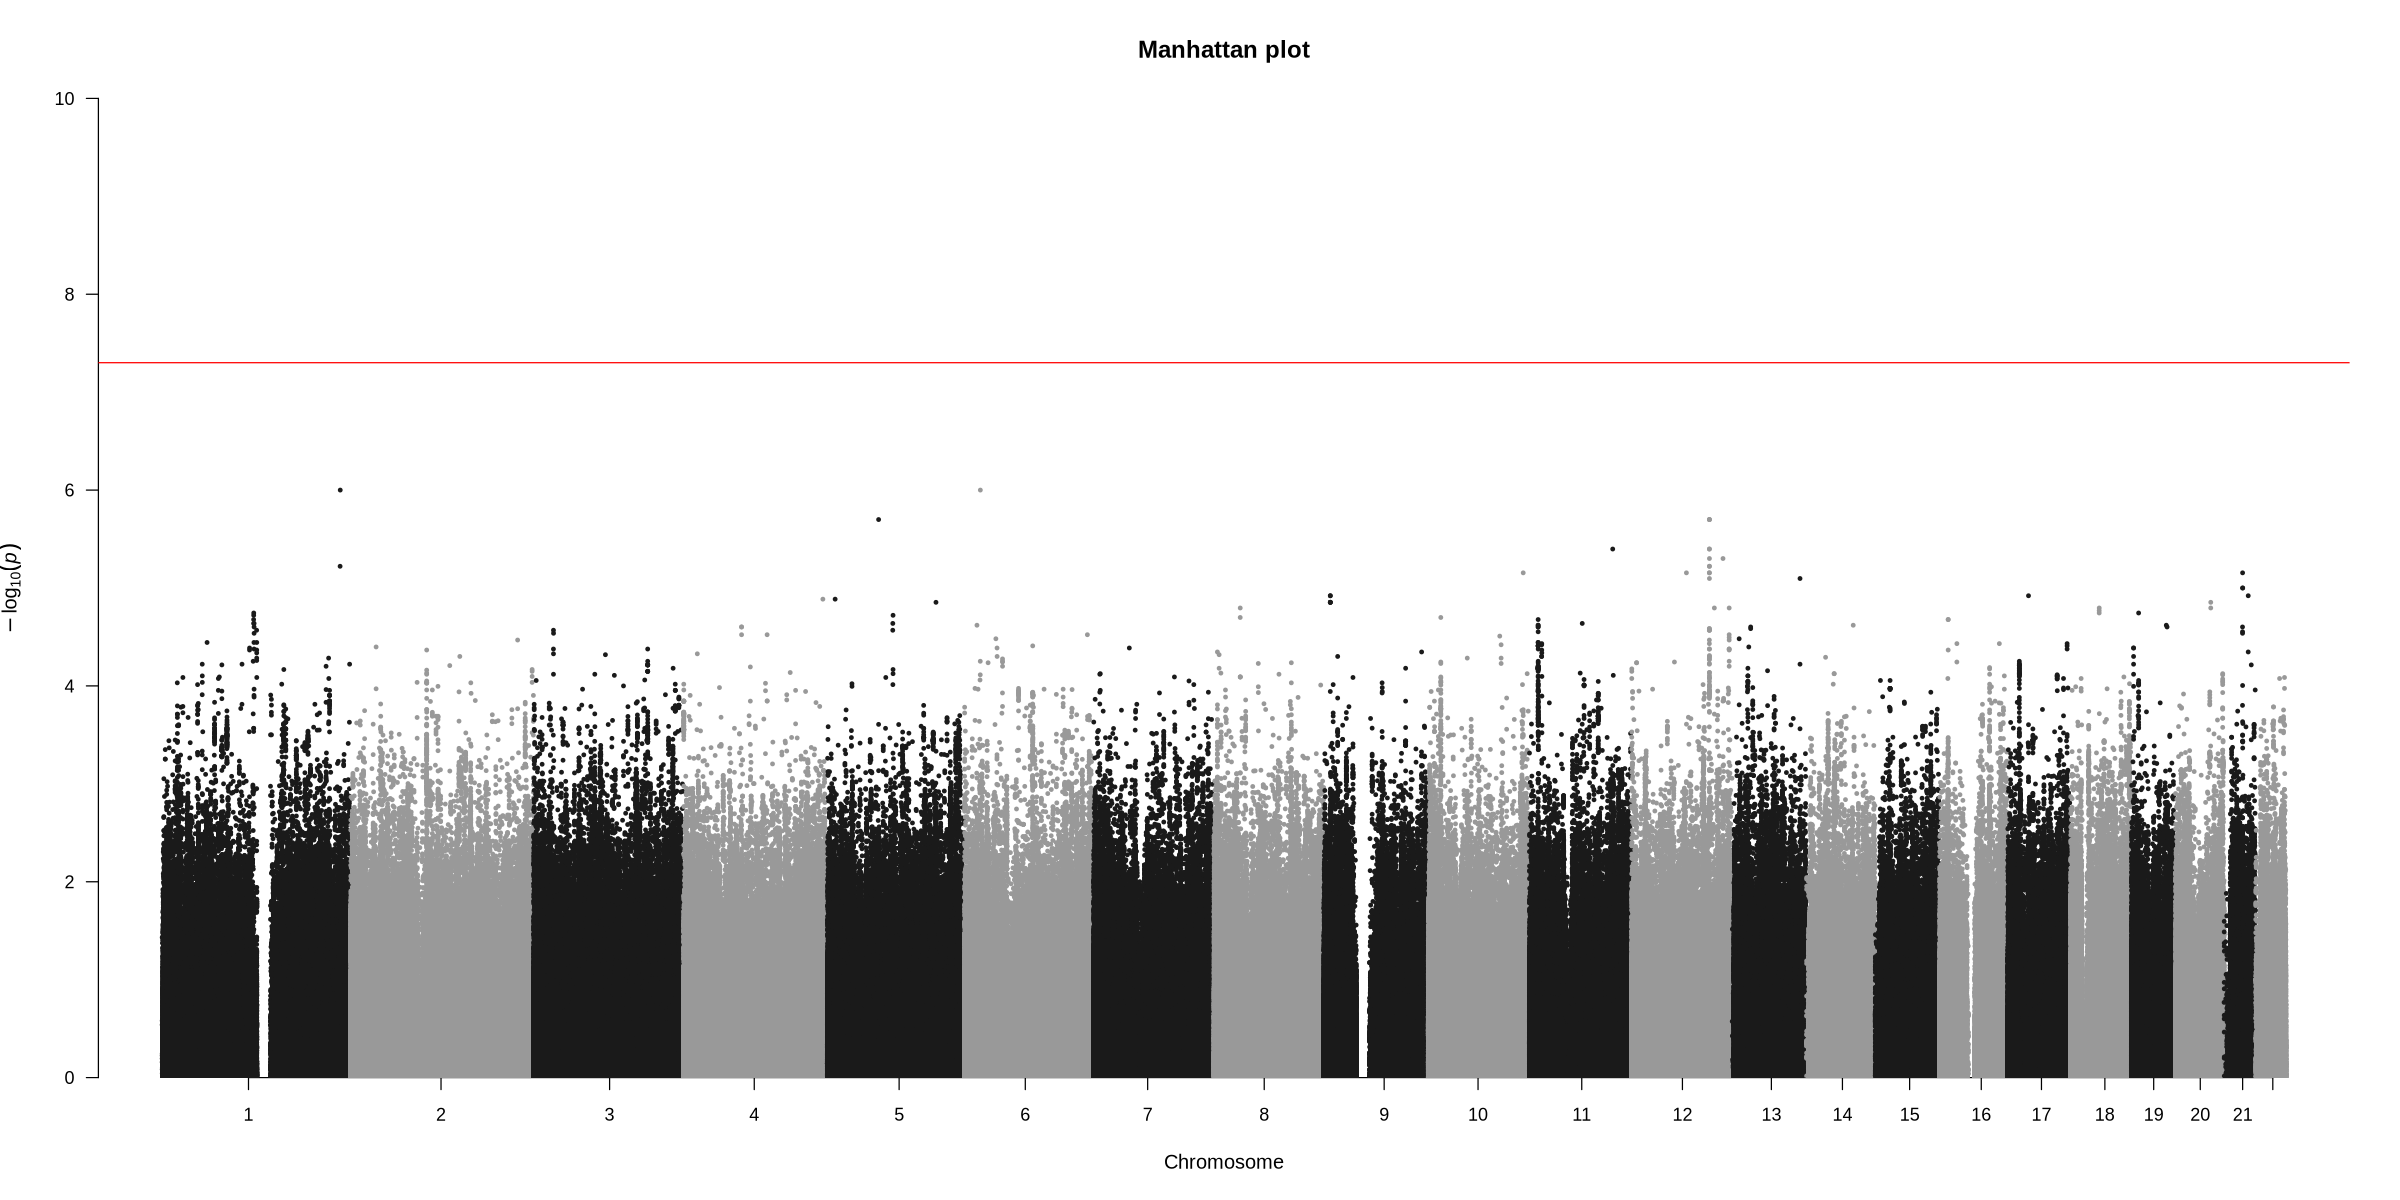

In [13]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = "Manhattan plot",
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, 10),
)

## QQ-plot

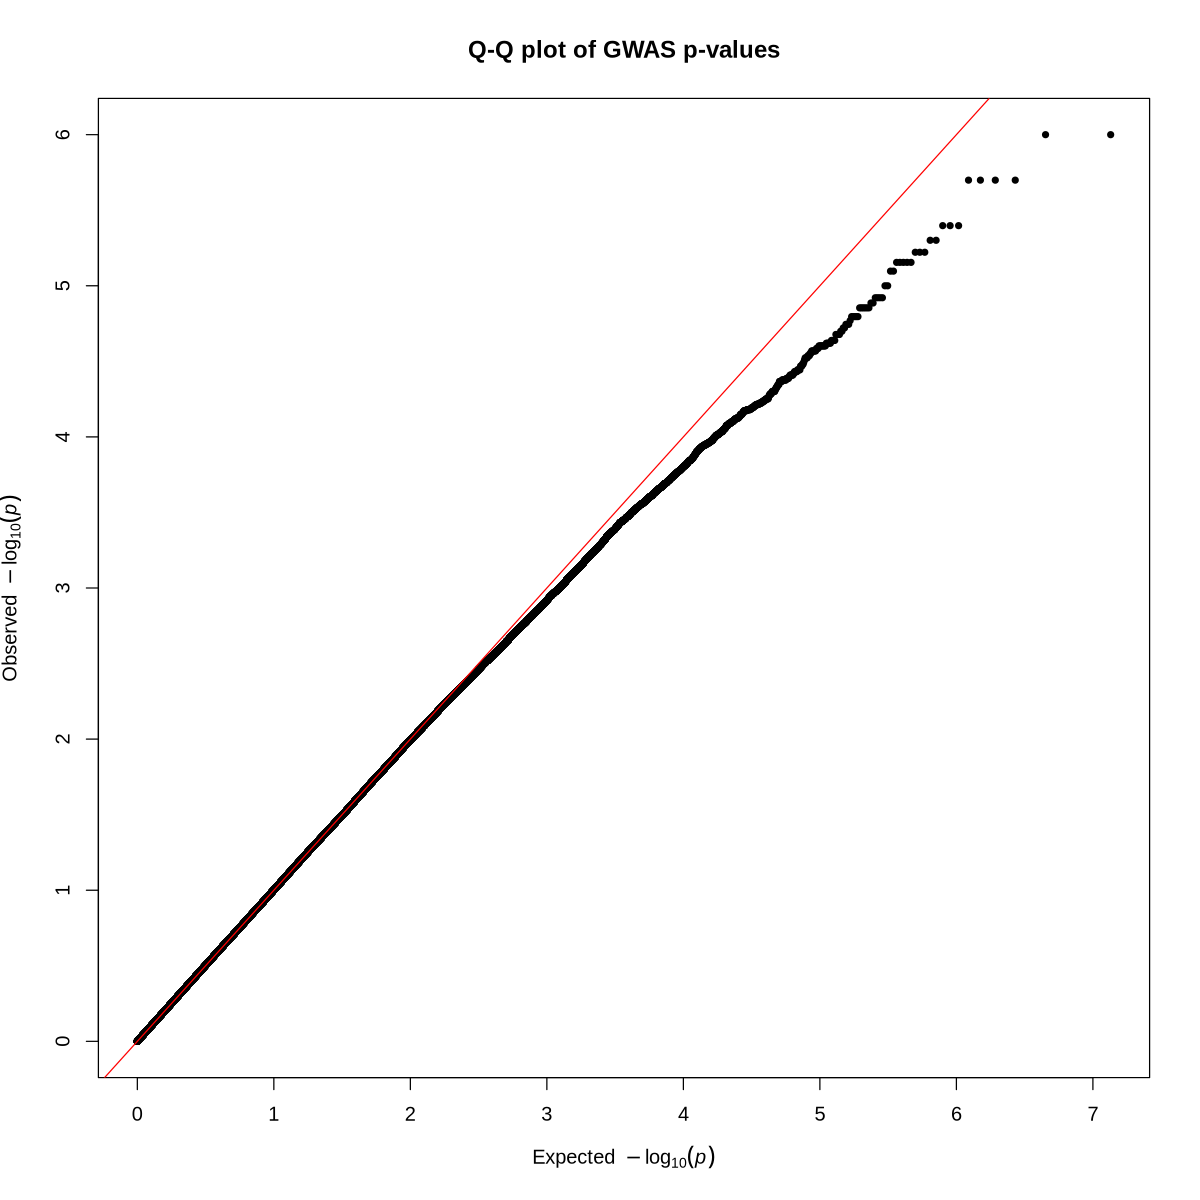

In [14]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(gwas$pvalue, main = "Q-Q plot of GWAS p-values")